In [14]:
import numpy as np
import os, glob, json
import pickle

import sys

# this is the path to the discovery folder
sys.path.insert(0, "./")
import discovery_new as ds

import matplotlib.pyplot as plt
import scipy
import jax.numpy as jnp

from scipy.stats import uniform
import jax

import copy

In [15]:
# this are the data we want to replicate
path = './dati/DR2low_feathers/'
s_dsfiles = np.sort(os.listdir(path))
psr = [ds.pulsar.Pulsar.read_feather(path + f'{psrfile}') for psrfile in s_dsfiles][9]

In [16]:
###### Let's put in the model the components we want to simulate (comment a line if you don't want to inject that process)
## cella con GWB
# data
model = [psr.residuals]
# timing model
model += [ds.makegp_timing(psr, svd=True, variance=1e-40)]
# white noise parameters
model += [ds.makenoise_measurement(psr, psr.noisedict, tnequad = True, ecorr=True)]
# red noise paramters
model.append(ds.makegp_fourier(psr, ds.powerlaw, psr.noisedict[psr.name + '_red_components'], T=ds.getspan(psr), name='red_noise' ))
# gwb paramters
model.append(ds.makegp_fourier(psr, ds.powerlaw, 20, T=ds.getspan(psr), name='gwb'))
# DM variation parameters
model.append(ds.makegp_fourier(psr, ds.powerlaw, psr.noisedict[psr.name + '_dm_components'], T=ds.getspan(psr), name='dm_gp', fourierbasis=ds.make_dmfourierbasis(alpha = 2.0, tndm = False)))
# scattering noise parameters
model.append(ds.makegp_fourier(psr, ds.powerlaw, psr.noisedict[psr.name + '_chrom_components'], T=ds.getspan(psr), name='sv_gp', fourierbasis=ds.make_dmfourierbasis(alpha = 4.0, tndm = False)))

In [17]:
gml = ds.PulsarLikelihood(model)
logL = ds.PulsarLikelihood(model).logL

In [18]:
logL.params

['J1640+2224_dm_gp_gamma',
 'J1640+2224_dm_gp_log10_A',
 'J1640+2224_gwb_gamma',
 'J1640+2224_gwb_log10_A',
 'J1640+2224_red_noise_gamma',
 'J1640+2224_red_noise_log10_A',
 'J1640+2224_sv_gp_gamma',
 'J1640+2224_sv_gp_log10_A']

In [19]:
# cella con GWB
truths = {
    'J1640+2224_dm_gp_gamma': 6.471070651479037,
    'J1640+2224_dm_gp_log10_A': -15.7227863246785,
    'J1640+2224_red_noise_gamma': 0.13235259553929019,
    'J1640+2224_red_noise_log10_A': -13.212902548624186,
    'J1640+2224_sv_gp_gamma': 1.3259815720503758,
    'J1640+2224_sv_gp_log10_A': -15.888300265911965,
    # GWB
    'J1640+2224_gwb_gamma': 13/3,
    'J1640+2224_gwb_log10_A': -15.5,
}

In [20]:
# sample from the likelihood! jax.random.key(42) is the seed of the random extraction, you can change it to have a different realisation od the data simulated
_, residuals = gml.sample(jax.random.key(1), truths)

In [21]:
# make a copy of the pulsar object and overwite the residuals with the simulated ones
sim_psr = copy.deepcopy(psr)
sim_psr.residuals = np.array(residuals)

In [22]:
import os
dirpath = 'sim_data_noiseGWBprova/'
if not os.path.exists(dirpath):
        os.makedirs(dirpath)

ds.pulsar.Pulsar.save_feather(sim_psr, dirpath + psr.name, noisedict=psr.noisedict)

In [23]:
print(os.getcwd())
print(os.path.abspath(dirpath))
print(os.listdir(dirpath))

/Users/lorenzocaivano/Desktop/Anno3Fisica/Tesi
/Users/lorenzocaivano/Desktop/Anno3Fisica/Tesi/sim_data_noiseGWBprova
['J1640+2224']


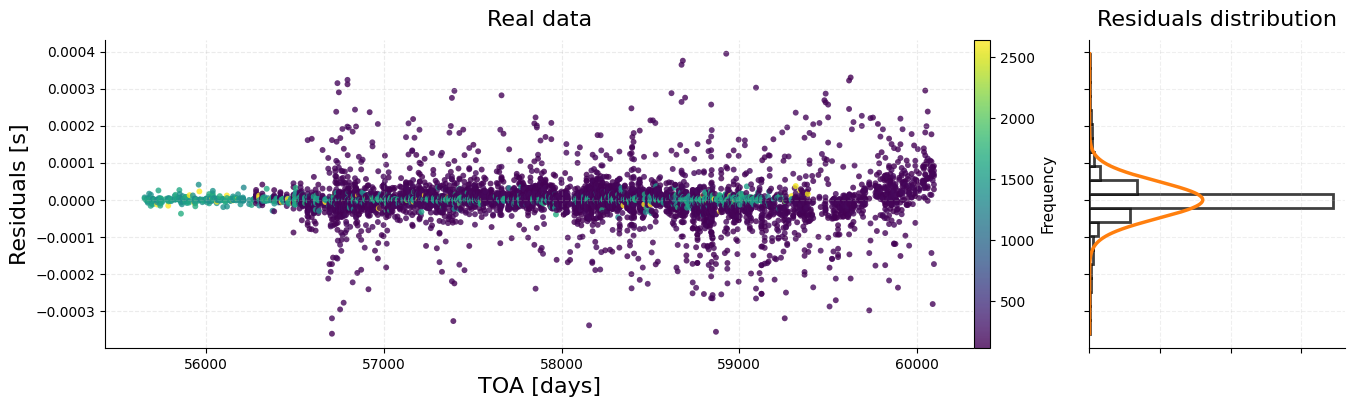

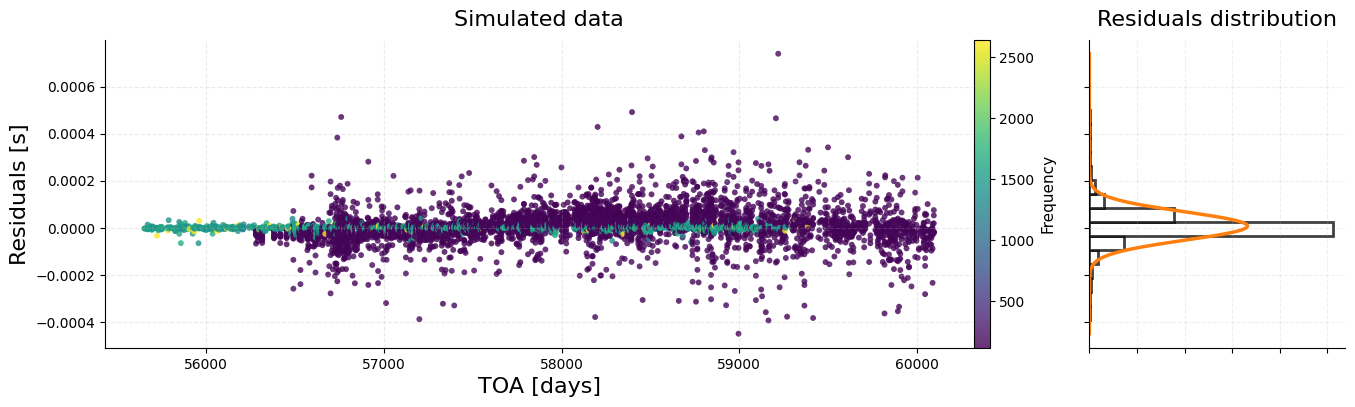

In [24]:
####################### original residuals ###############################################################################

fig, ax = plt.subplots(
    1, 2,
    figsize=(16, 4),
    gridspec_kw={'width_ratios': [4, 1]},
    sharey=True
)

sc = ax[0].scatter(psr.toas / 86400, psr.residuals, c=psr.freqs, s=18, alpha=0.8, cmap='viridis', edgecolors='none')

ax[0].set_xlabel("TOA [days]", fontsize=16)
ax[0].set_ylabel("Residuals [s]", fontsize=16)
ax[0].set_title("Real data", fontsize=16, pad=10)


ax[0].grid(alpha=0.25, linestyle='--')
ax[0].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)

ax[1].hist(psr.residuals, bins=20, orientation='horizontal', color='w', alpha=0.75, edgecolor='black', linewidth=2, density=True)

mu, sigma = np.mean(psr.residuals), np.std(psr.residuals)

y = np.linspace(psr.residuals.min(), psr.residuals.max(), 500)
pdf = scipy.stats.norm.pdf(y, mu, sigma)

# Overlay Gaussian
ax[1].plot(pdf, y, color='tab:orange', linewidth=2.5, label=fr'$\mu={mu:.2e}$' + '\n' + fr'$\sigma={sigma:.2e}$')

ax[1].set_title("Residuals distribution", fontsize=16, pad=10)
ax[1].grid(alpha=0.2, linestyle='--')


ax[1].tick_params(axis='y', labelleft=False)
ax[1].tick_params(axis='x', right=False, labelbottom=False)

ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)

cbar = fig.colorbar(sc, ax=ax[0], pad=0.001)
cbar.set_label("Frequency", fontsize=11)


fig.subplots_adjust(wspace=-0.06)

plt.show()

####################### simulated residuals ###############################################################################

fig, ax = plt.subplots(
    1, 2,
    figsize=(16, 4),
    gridspec_kw={'width_ratios': [4, 1]},
    sharey=True
)

sc = ax[0].scatter(sim_psr.toas / 86400, sim_psr.residuals, c=sim_psr.freqs, s=18, alpha=0.8, cmap='viridis', edgecolors='none')

ax[0].set_xlabel("TOA [days]", fontsize=16)
ax[0].set_ylabel("Residuals [s]", fontsize=16)
ax[0].set_title("Simulated data", fontsize=16, pad=10)


ax[0].grid(alpha=0.25, linestyle='--')
ax[0].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)

ax[1].hist(sim_psr.residuals, bins=20, orientation='horizontal', color='w', alpha=0.75, edgecolor='black', linewidth=2, density=True)

mu, sigma = np.mean(sim_psr.residuals), np.std(sim_psr.residuals)

y = np.linspace(sim_psr.residuals.min(), sim_psr.residuals.max(), 500)
pdf = scipy.stats.norm.pdf(y, mu, sigma)

# Overlay Gaussian
ax[1].plot(pdf, y, color='tab:orange', linewidth=2.5, label=fr'$\mu={mu:.2e}$' + '\n' + fr'$\sigma={sigma:.2e}$')

ax[1].set_title("Residuals distribution", fontsize=16, pad=10)
ax[1].grid(alpha=0.2, linestyle='--')


ax[1].tick_params(axis='y', labelleft=False)
ax[1].tick_params(axis='x', right=False, labelbottom=False)

ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)

cbar = fig.colorbar(sc, ax=ax[0], pad=0.001)
cbar.set_label("Frequency", fontsize=11)


fig.subplots_adjust(wspace=-0.06)

plt.show()

In [12]:
print(sorted(logL.params))
print(sorted(truths.keys()))
assert set(logL.params) == set(truths.keys()), \
    f"Mancanti: {set(logL.params) - set(truths.keys())}\nIn eccesso: {set(truths.keys()) - set(logL.params)}"

['J1640+2224_dm_gp_gamma', 'J1640+2224_dm_gp_log10_A', 'J1640+2224_gwb_gamma', 'J1640+2224_gwb_log10_A', 'J1640+2224_red_noise_gamma', 'J1640+2224_red_noise_log10_A', 'J1640+2224_sv_gp_gamma', 'J1640+2224_sv_gp_log10_A']
['J1640+2224_dm_gp_gamma', 'J1640+2224_dm_gp_log10_A', 'J1640+2224_gwb_gamma', 'J1640+2224_gwb_log10_A', 'J1640+2224_red_noise_gamma', 'J1640+2224_red_noise_log10_A', 'J1640+2224_sv_gp_gamma', 'J1640+2224_sv_gp_log10_A']


In [13]:
check = ds.pulsar.Pulsar.read_feather('sim_data_noise/J1640+2224')
print('std residui salvati:', np.std(check.residuals))
print('N_TOA              :', len(check.toas))

std residui salvati: 8.292204526213539e-05
N_TOA              : 6777
